In [32]:
from qutip import *
import numpy as np
import matplotlib.pyplot as plt
import scqubits as scq
#%matplotlib qt

In [33]:
GHz = 1e9
MHz = 1e6
KHz = 1e3
pi = np.pi #
n_res = 150
fr = 7.167
# Taking planck's constant to be 1 ,consequence is energy scales are in frequency
# Frequencies are taken in GHz unit meaning , 7 GHz is 7 

In [34]:
# With Qobj Ket is a column vector whereas Bra is row vector and square matrix is operator
def Ham_res(N=1):
    # N  is  number of resonator levels
    print(fr)
    H_res = fr*create(N)*destroy(N) # Readout resonator with 200 levels
    return H_res

In [35]:
# Setting up bare fluxonium hamiltonian
m = 19 # number of transmon levels
Ej = 2.936 #/2/pi
Ec = 0.730 #/2/pi
El = 0.891 #/2/pi
phi_ext = 0.5 #*2*pi
flx = scq.Fluxonium(Ej,Ec,El,phi_ext,cutoff = m)
H_flx = Qobj(flx.hamiltonian())
n_flx = Qobj(flx.n_operator())
# Eigen energies and eigenstate of transmon
E_flx, S_flx = H_flx.eigenstates()
E_flx = E_flx - E_flx[0]
print(E_flx[0],E_flx[1],E_flx[2]-E_flx[1])

0.0 0.5639690514586753 2.4422803962633193


In [36]:
# Setting up bare resonator
H_r = Ham_res(n_res)
# Eigen energies and eigenstate of resonator
E_r , S_r = H_r.eigenstates()
E_r = E_r - E_r[0]

7.167


In [37]:
# Coupling hamilotnian
def Ham_int(N=1,g = 0.1):
    # g = 0.1 is 100 MHz
    H_g = (-1j) * g * tensor((create(N)-destroy(N)),n_flx) 

    # To work with full hibert space , we need to take tensor products with identity operator , convention is tensor(readout,flxuonium)

    H_res_f = tensor(Ham_res(N),qeye(m))
    H_flx_f = tensor(qeye(N),H_flx)

    # Interaction hamiltonian

    H_f = H_res_f + H_flx_f + H_g
    return H_f

In [38]:
# Next for branch reference we assign energy levels and eigens states of 0 resontor population

In [39]:
E_flx[20:]

array([], dtype=float64)

In [40]:
SHam_final = Ham_int(n_res,0.289)

7.167


In [41]:
E_rf, S_rf = SHam_final.eigenstates()

In [42]:
print(S_rf)

[Quantum object: dims=[[150, 19], [1]], shape=(2850, 1), type='ket', dtype=Dense
 Qobj data =
 [[ 8.75529804e-001]
  [-1.11022302e-016]
  [ 4.81792337e-001]
  ...
  [-1.31624133e-101]
  [-2.00589524e-081]
  [ 1.60805864e-101]]
 Quantum object: dims=[[150, 19], [1]], shape=(2850, 1), type='ket', dtype=Dense
 Qobj data =
 [[ 2.84460608e-016]
  [ 9.51231223e-001]
  [-4.62792405e-016]
  ...
  [ 0.00000000e+000]
  [-1.14689336e-156]
  [ 0.00000000e+000]]
 Quantum object: dims=[[150, 19], [1]], shape=(2850, 1), type='ket', dtype=Dense
 Qobj data =
 [[-4.68748818e-01]
  [-1.11022302e-16]
  [ 8.44706257e-01]
  ...
  [ 0.00000000e+00]
  [ 0.00000000e+00]
  [ 0.00000000e+00]]
 ...
 Quantum object: dims=[[150, 19], [1]], shape=(2850, 1), type='ket', dtype=Dense
 Qobj data =
 [[ 0.00000000e+00]
  [-6.85795133e-21]
  [-2.92912880e-31]
  ...
  [ 3.97820492e-01]
  [-3.59739271e-17]
  [ 6.20219207e-01]]
 Quantum object: dims=[[150, 19], [1]], shape=(2850, 1), type='ket', dtype=Dense
 Qobj data =
 [[ 0

In [43]:
E_rf=E_rf-E_rf[0]

In [44]:
# Dispersive shift for the particular choice of parameters
print(E_rf[5],E_rf[1],E_rf[4],E_rf[0], E_rf[2], E_rf[3])
E_rf[5]-E_rf[1]-E_rf[4]+E_rf[0]

7.6065188571992515 0.5613619386072715 7.170808572629525 0.0 2.9966862119397746 5.101381637388112


np.float64(-0.1256516540375454)

In [45]:
indx_0 = [] # Indices corresponding fluxonium level with nr=0
indx_bare = []
for i in range(0,19):
    temp = 0.1
    for j in range(0,500):
        if np.abs(E_rf[j]-E_flx[i])<temp:
            temp = np.abs(E_rf[j]-E_flx[i])
            temp1 = j
    indx_0.append(temp1)
    indx_bare.append(i)

print(indx_0,  indx_bare)
for i in range(0, 19):
    print(f"Bare state energy : {indx_bare[i]} Dressed state energy : {indx_0[i]} \n")
# Next step is to find indices with state nr+1
# For now I am just considering Fluxonium Ground and Excited level branch
#indx_0 = indx_0[:2]        

[0, 1, 2, 3, 5, 8, 10, 14, 17, 20, 25, 28, 31, 35, 40, 44, 52, 58, 64] [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
Bare state energy : 0 Dressed state energy : 0 

Bare state energy : 1 Dressed state energy : 1 

Bare state energy : 2 Dressed state energy : 2 

Bare state energy : 3 Dressed state energy : 3 

Bare state energy : 4 Dressed state energy : 5 

Bare state energy : 5 Dressed state energy : 8 

Bare state energy : 6 Dressed state energy : 10 

Bare state energy : 7 Dressed state energy : 14 

Bare state energy : 8 Dressed state energy : 17 

Bare state energy : 9 Dressed state energy : 20 

Bare state energy : 10 Dressed state energy : 25 

Bare state energy : 11 Dressed state energy : 28 

Bare state energy : 12 Dressed state energy : 31 

Bare state energy : 13 Dressed state energy : 35 

Bare state energy : 14 Dressed state energy : 40 

Bare state energy : 15 Dressed state energy : 44 

Bare state energy : 16 Dressed state energy : 52 

Bare state 

In [46]:
np.size(indx_0) , np.size(E_rf)

(19, 2850)

In [47]:
print(E_rf.size)

2850


In [48]:
indx_mat = []
cr_opr = tensor(create(n_res),qeye(m))# creation operator for resonator photon 
branch_num = 19 # number of branches we explore
lvls=np.size(E_rf)
#for k in range(200):
#    temp_indx= []
for j in range(branch_num):
    temp2 = indx_0[j]
    temp_indx = [temp2]
    print(temp_indx)
    for k in range(43): # Number of photons to consider
        temp = 0
        B = S_rf[temp2]  # Previous state in the branch
        for i in range(lvls):
            A = S_rf[i] # States to be scanned
            # oeverlap of state with creation of next resonator photon  ovrlap = (cr_opr*B).overlap(A) and ovrlap_c = np.conj(ovrlap`)
            ovrlap = (cr_opr*B).overlap(A)
            expct = ovrlap*np.conj(ovrlap)
            #expct = (np.abs(A.dag()*cr_opr*B))**2
            if expct > temp:
                temp = expct
                temp2 = i
        temp_indx.append(temp2)
    indx_mat.append(temp_indx)    

    

[0]
[1]
[2]
[3]
[5]
[8]
[10]
[14]
[17]
[20]
[25]
[28]
[31]
[35]
[40]
[44]
[52]
[58]
[64]


In [49]:
for i in range(0,19):
    print(indx_mat[i])

[0, 4, 11, 21, 34, 51, 70, 89, 108, 127, 146, 165, 184, 203, 222, 241, 260, 279, 298, 317, 336, 355, 374, 393, 412, 431, 450, 469, 488, 507, 526, 545, 564, 583, 602, 621, 640, 659, 678, 697, 716, 735, 754, 773]
[1, 6, 13, 23, 37, 54, 73, 92, 111, 130, 149, 168, 187, 206, 225, 244, 263, 282, 301, 320, 339, 358, 377, 396, 415, 434, 453, 472, 491, 510, 529, 548, 567, 586, 605, 624, 643, 662, 681, 700, 719, 738, 757, 776]
[2, 7, 15, 26, 41, 59, 77, 96, 115, 134, 153, 172, 191, 210, 229, 248, 267, 287, 306, 325, 344, 363, 382, 401, 420, 439, 458, 477, 496, 515, 534, 553, 572, 591, 610, 629, 648, 667, 686, 705, 724, 743, 762, 781]
[3, 9, 18, 30, 46, 65, 84, 103, 122, 141, 160, 179, 198, 217, 236, 255, 274, 293, 312, 331, 350, 369, 388, 407, 426, 445, 464, 483, 502, 521, 540, 559, 578, 597, 616, 635, 654, 673, 692, 711, 730, 749, 768, 787]
[5, 12, 22, 36, 52, 71, 90, 109, 128, 147, 166, 185, 204, 223, 242, 261, 280, 299, 318, 337, 356, 375, 394, 413, 432, 451, 470, 489, 508, 527, 546, 565, 58

In [50]:
for i , j in enumerate(indx_mat):
    print(i)
    print(j)

0
[0, 4, 11, 21, 34, 51, 70, 89, 108, 127, 146, 165, 184, 203, 222, 241, 260, 279, 298, 317, 336, 355, 374, 393, 412, 431, 450, 469, 488, 507, 526, 545, 564, 583, 602, 621, 640, 659, 678, 697, 716, 735, 754, 773]
1
[1, 6, 13, 23, 37, 54, 73, 92, 111, 130, 149, 168, 187, 206, 225, 244, 263, 282, 301, 320, 339, 358, 377, 396, 415, 434, 453, 472, 491, 510, 529, 548, 567, 586, 605, 624, 643, 662, 681, 700, 719, 738, 757, 776]
2
[2, 7, 15, 26, 41, 59, 77, 96, 115, 134, 153, 172, 191, 210, 229, 248, 267, 287, 306, 325, 344, 363, 382, 401, 420, 439, 458, 477, 496, 515, 534, 553, 572, 591, 610, 629, 648, 667, 686, 705, 724, 743, 762, 781]
3
[3, 9, 18, 30, 46, 65, 84, 103, 122, 141, 160, 179, 198, 217, 236, 255, 274, 293, 312, 331, 350, 369, 388, 407, 426, 445, 464, 483, 502, 521, 540, 559, 578, 597, 616, 635, 654, 673, 692, 711, 730, 749, 768, 787]
4
[5, 12, 22, 36, 52, 71, 90, 109, 128, 147, 166, 185, 204, 223, 242, 261, 280, 299, 318, 337, 356, 375, 394, 413, 432, 451, 470, 489, 508, 527, 54

In [51]:
np.size(indx_mat[0]) , E_rf[2]

(44, np.float64(2.9966862119397746))

In [52]:
branch = E_rf[indx_mat]

Text(0.5, 1.0, 'Coupling = 90MHz; Freq of rr = 7.0911 GHz')

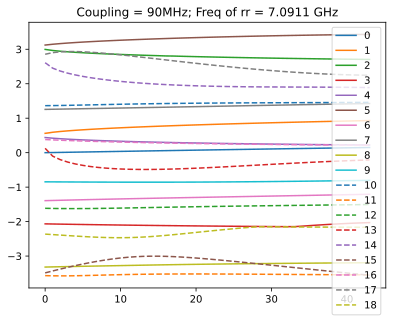

In [53]:
plt.figure()
for i in range(branch_num):
    br_e = [x%fr for x in branch[i]]
    #br_e = [x if x<=3.75 else 3.75-x for x in br_e]
    for a,x in enumerate(br_e):
        if x<=fr/2:
            br_e[a] = x
        else:
            br_e[a] = x-fr
    #br_e = [x if x<=3.75 else x-7.5 for x in br_e]
    if i<10:
        plt.plot(br_e, label = f'{i}')
    elif 10<=i<20:
        plt.plot(br_e, label = f'{i}',ls='--')
    else:
        plt.plot(br_e, label = f'{i}',ls=':')
#plt.xlim(0,170)
#plt.ylim(-3.74,3.74)
plt.legend()
plt.title("Coupling = 90MHz; Freq of rr = 7.0911 GHz")

In [54]:
# de_opr = tensor(destroy(n_res),qeye(m))
# Nq = []
# Nr = []
# for k in range(branch_num):
#     nq = []
#     nr = []
#     for i,j in enumerate(indx_mat[k]):
#         C = S_rf[j]
#         exct_num = 0
#         for l in range(n_res):
#             for s in range(m):
#                 D = tensor(S_r[l],S_flx[s])
#                 exct_num = s*(abs(D.dag()*C))**2 + exct_num
#         nq.append(exct_num)
#         nr.append(abs(C.dag()*cr_opr*de_opr*C))
#     Nq.append(nq)
#     Nr.append(nr)

de_opr = tensor(destroy(n_res), qeye(m))
Nq = []
Nr = []

for k in range(branch_num):
    nq = []
    nr = []

    for i, j in enumerate(indx_mat[k]):
        C = S_rf[j]
        print(C)
        exct_num = 0

        for l in range(n_res):
            for s in range(m):
                D = tensor(S_r[l], S_flx[s])

                # compute |<D|C>|^2
                overlap = D.overlap(C)
                exct_num += s * np.abs(overlap)**2

        nq.append(exct_num)

        # number operator expectation value
        #nr.append(np.abs((C.dag() * cr_opr * de_opr * C).full()[0, 0]))
        nr.append(expect((cr_opr * de_opr), C))

    Nq.append(nq)
    Nr.append(nr)


Quantum object: dims=[[150, 19], [1]], shape=(2850, 1), type='ket', dtype=Dense
Qobj data =
[[ 8.75529804e-001]
 [-1.11022302e-016]
 [ 4.81792337e-001]
 ...
 [-1.31624133e-101]
 [-2.00589524e-081]
 [ 1.60805864e-101]]
Quantum object: dims=[[150, 19], [1]], shape=(2850, 1), type='ket', dtype=Dense
Qobj data =
[[ 1.05717819e-17]
 [-5.52720584e-03]
 [ 4.19913346e-18]
 ...
 [ 2.91346832e-84]
 [ 7.59710863e-64]
 [-1.45487099e-84]]
Quantum object: dims=[[150, 19], [1]], shape=(2850, 1), type='ket', dtype=Dense
Qobj data =
[[ 2.84815752e-004]
 [ 5.92841748e-016]
 [-1.36853199e-003]
 ...
 [-2.29744713e-110]
 [-9.64662298e-090]
 [ 1.12218493e-110]]
Quantum object: dims=[[150, 19], [1]], shape=(2850, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.00000000e+00]
 [ 2.77557607e-05]
 [ 1.15646761e-17]
 ...
 [-2.85937382e-29]
 [ 4.56914029e-22]
 [ 3.38354974e-29]]
Quantum object: dims=[[150, 19], [1]], shape=(2850, 1), type='ket', dtype=Dense
Qobj data =
[[-3.39910499e-07]
 [-3.47774787e-17]
 [ 1.47600

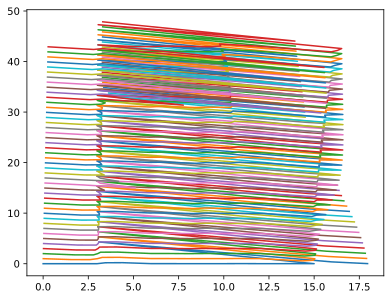

In [55]:
plt.plot(Nq,Nr)

(0.0, 20.0)

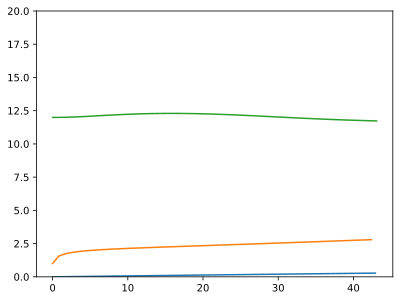

In [56]:
plt.plot(Nr[0], Nq[0])
plt.plot(Nr[1], Nq[1])
# plt.plot(Nr[0], Nq[2])
# plt.plot(Nr[0], Nq[3])
# plt.plot(Nr[0], Nq[4])
# plt.plot(Nr[0], Nq[5])
# plt.plot(Nr[0], Nq[6])
# plt.plot(Nr[0], Nq[7])
# plt.plot(Nr[0], Nq[8])
# plt.plot(Nr[0], Nq[9])
# plt.plot(Nr[0], Nq[10])
# plt.plot(Nr[0], Nq[11])
plt.plot(Nr[12], Nq[12])
# plt.plot(Nr[0], Nq[13])
# plt.plot(Nr[0], Nq[14])
# plt.plot(Nr[0], Nq[15])
# plt.plot(Nr[0], Nq[16])
# plt.plot(Nr[0], Nq[17])
# plt.plot(Nr[0], Nq[18])
# plt.plot(Nr[0], Nq[19])
plt.ylim(0,20)


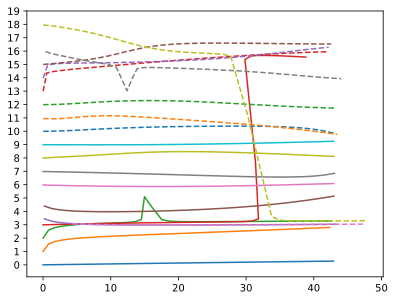

In [57]:
plt.figure()
for k in range(branch_num):
    if k<10:
        plt.plot(Nr[k],Nq[k],label = f"{k}")
    elif 10<=k<20:
        plt.plot(Nr[k],Nq[k],label = f"{k}",ls='--')
    else:
        plt.plot(Nr[k],Nq[k],label = f"{k}",ls=':')
plt.yscale("linear")
x = np.arange(0,20)
plt.yticks(x)
# plt.legend()
plt.show()
        #plt.plot(Nr_11,Nt_11)
#plt.plot(Nr_12,Nt_12)

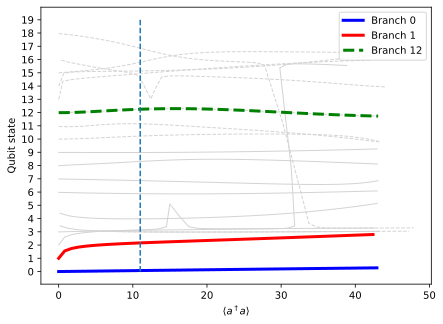

In [58]:
plt.figure(figsize=(7,5))

# Plot all branches faded
for k in range(branch_num):
    if k < 10:
        ls = '-'
    elif k < 20:
        ls = '--'
    else:
        ls = ':'

    plt.plot(Nr[k], Nq[k], ls=ls, color='lightgray', lw=1)

# Highlight selected branches
highlight = {
    0: ('blue', 3),
    1: ('red', 3),
    12: ('green', 3),
}

for k, (color, lw) in highlight.items():
    if k < 10:
        ls = '-'
    elif k < 20:
        ls = '--'
    else:
        ls = ':'

    plt.plot(Nr[k], Nq[k],
             color=color,
             lw=lw,
             ls=ls,
             label=f'Branch {k}')

plt.yticks(np.arange(20))
plt.xlabel(r'$\langle a^\dagger a \rangle$')
plt.ylabel('Qubit state')
plt.legend()
plt.vlines(11, 0, 19, linestyles="--")
plt.show()

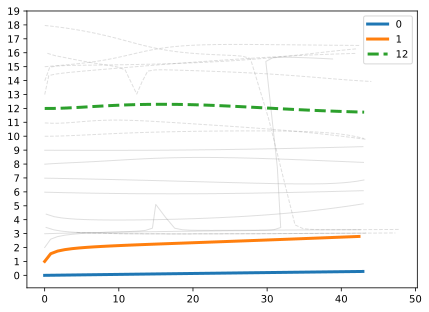

In [59]:
highlight = [0, 1, 12]

plt.figure(figsize=(7,5))

for k in range(branch_num):
    if k < 10:
        ls = '-'
    elif k < 20:
        ls = '--'
    else:
        ls = ':'

    if k in highlight:
        plt.plot(Nr[k], Nq[k], ls=ls, lw=3, label=f'{k}')
    else:
        plt.plot(Nr[k], Nq[k], ls=ls, color='gray', alpha=0.25, lw=1)

plt.yticks(np.arange(20))
plt.legend()
plt.show()

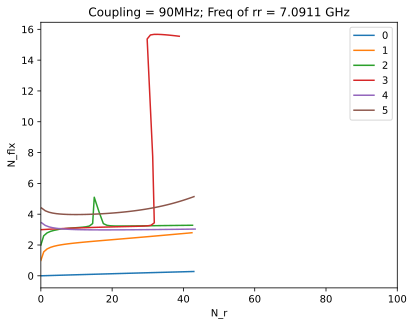

In [60]:
plt.figure()
for k in [0,1,2,3,4,5]: # 7,11,13,14,25,28
    if k<10:
        plt.plot(Nr[k],Nq[k],label = f"{k}")
    else:
        plt.plot(Nr[k],Nq[k],label = f"{k}",ls='--')
plt.legend()
plt.xlabel('N_r')
plt.ylabel('N_flx')
plt.xlim(0,100)
plt.title("Coupling = 90MHz; Freq of rr = 7.0911 GHz")
plt.legend()

Text(0.5, 1.0, 'Coupling = 90MHz; Freq of rr = 7.0911 GHz')

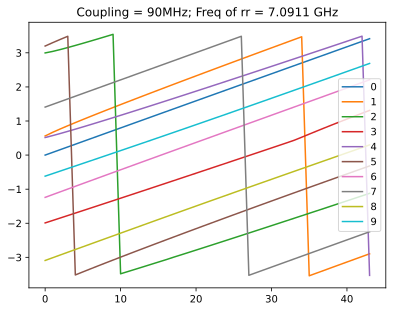

In [61]:
plt.figure()
for i in range(10):
    br_e = [x%7.0911 for x in branch[i]]
    #br_e = [x if x<=3.75 else 3.75-x for x in br_e]
    for a,x in enumerate(br_e):
        if x<=7.0911/2:
            br_e[a] = x
        else:
            br_e[a] = x-7.0911
    #br_e = [x if x<=3.75 else x-7.5 for x in br_e]
    if i<10:
        plt.plot(br_e, label = f'{i}')
    elif 10<=i<20:
        plt.plot(br_e, label = f'{i}',ls='--')
    else:
        plt.plot(br_e, label = f'{i}',ls=':')
#plt.xlim(0,170)
#plt.ylim(-3.74,3.74)
plt.legend()
plt.title("Coupling = 90MHz; Freq of rr = 7.0911 GHz")

In [62]:
E_flx

array([ 0.        ,  0.56396905,  3.00624945,  5.11982221,  7.65793858,
       10.28899878, 12.97525359, 15.63091991, 18.22812087, 20.70402202,
       22.91415578, 25.15592991, 27.10208489, 28.84929135, 31.33941398,
       32.39424233, 36.1341316 , 38.64567143, 40.67904099])